# Disease Vectors Analogical Reasoning

In this notebook, we show how to use our model to compute disease vectors.  quantify how related they are analogically. 

## Getting the relevant slice of our dataset

In [1]:
import os
import pandas as pd
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
save_path = '/media/rohola/ssd_storage/primary_metadata/'

DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiometabolic': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']}

files = sorted(os.listdir(save_path))
df = pd.concat([pd.read_pickle(save_path+f) for f in files], ignore_index=True)

In [ ]:
# Get counts of cell types per disease
results=[];print(df.shape)
for d in sum(list(DISEASES_DICT.values()),[]):
    t=df[df['disease']==d].value_counts(['cell_type','tissue_general']).reset_index().head(3)
    t.columns=['cell_type','tissue_general',d];results.append(t)
display(pd.concat(results,axis=1))

(35750000, 27)


,cell_type,tissue_general,COVID-19,cell_type,tissue_general,influenza,cell_type,tissue_general,lung adenocarcinoma,cell_type,...,glioblastoma,cell_type,tissue_general,myocardial infarction,cell_type,tissue_general,dilated cardiomyopathy,cell_type,tissue_general,arrhythmogenic right ventricular cardiomyopathy
0,B cell,blood,500239,classical monocyte,blood,11473,"CD4-positive, alpha-beta T cell",lung,125029,neuron,...,409290,cardiac muscle myoblast,heart,50330,cardiac muscle cell,heart,149631,fibroblast of cardiac tissue,heart,25113
1,"CD8-positive, alpha-beta T cell",blood,484430,"CD4-positive, alpha-beta T cell",blood,5369,"CD8-positive, alpha-beta T cell",lung,99858,microglial cell,...,275761,fibroblast of cardiac tissue,heart,43717,mural cell,heart,97754,cardiac muscle cell,heart,24592
2,"CD4-positive, alpha-beta T cell",blood,371921,"CD8-positive, alpha-beta T cell",blood,3956,alveolar macrophage,lung,68185,T cell,...,205025,cardiac endothelial cell,heart,31904,endothelial cell,heart,83890,mural cell,heart,22561


In [7]:
DISEASES_DICT = {
                'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiac': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']
                }

CELL_TYPE_DICT = {
                'COVID-19': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'B cell', 'classical monocyte'],
                  'influenza': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'classical monocyte'],
                  'lung adenocarcinoma': ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'B cell'],
                  'Alzheimer disease': ['neuron', 'microglial cell'],
                  'Parkinson disease':['oligodendrocyte', 'neuron', 'microglial cell', 'astrocyte', 'endothelial cell'],
                  'glioblastoma':['malignant cell', 'microglial cell', 'endothelial cell', 'oligodendrocyte', 'monocyte'],
                  'myocardial infarction':['cardiac muscle myoblast', 'fibroblast of cardiac tissue', 'cardiac endothelial cell'],
                  'dilated cardiomyopathy':['cardiac muscle cell', 'fibroblast of cardiac tissue', 'endothelial cell'],
                  'arrhythmogenic right ventricular cardiomyopathy' :['fibroblast of cardiac tissue', 'cardiac muscle cell', 'endothelial cell']
                  }

TISSUE_DICT = {
                'COVID-19': ['blood'],
                  'influenza': ['blood'],
                  'lung adenocarcinoma': ['lung'],
                  'Alzheimer disease': ['brain'],
                  'Parkinson disease':['brain'],
                  'glioblastoma':['brain'],
                  'myocardial infarction':['heart'],
                  'dilated cardiomyopathy':['heart'],
                  'arrhythmogenic right ventricular cardiomyopathy' :['heart']
                  }

The rest is executed in the script get_cells_for_vectors.py

## Analysis

In [89]:
SAVE = False

In [90]:
import scanpy as sc, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch
from matplotlib.lines import Line2D
from scipy.spatial.distance import pdist
def plot_umap(df, disease_label, labels, palette_dict, reduction='umap', endotype_matching=False, figure_size=(8,6), marker_size=40, save_path=None, alpha=0.8, lw=0.1, fontsize=12, eps=5.0, min_samples=50 ):

    if endotype_matching:
        print('Cluster removal filtration epsilon', eps, "min and max", df[['UMAP1','UMAP2']].min().tolist(), df[['UMAP1','UMAP2']].max().tolist())
        keep_indices = []
        for (cell_type, disease), g in df.groupby(['cell_type','disease']):
            lab = DBSCAN(eps=eps, min_samples=min_samples).fit(g[['UMAP1','UMAP2']]).labels_
            s = pd.Series(lab, index=g.index)
            if (s!=-1).any():
                main = s[s!=-1].value_counts().idxmax()
                keep_indices.append(s.index[s==main])
        if len(keep_indices)==0:
            return
        keep_indices = np.concatenate([i.values for i in keep_indices])
        df_plot = df.loc[keep_indices]
    else: df_plot = df

    fig, ax = plt.subplots(figsize=figure_size, dpi=300 if SAVE else 100)
    hue_vals = labels if isinstance(labels, str) else labels.loc[df_plot.index]
    sns.scatterplot(data=df_plot, x='UMAP1', y='UMAP2', hue=hue_vals, palette=palette_dict, s=marker_size, alpha=alpha, ax=ax, linewidth=lw, zorder=1)# edgecolor='k'
    ax.set_axisbelow(True)

    disease_vectors = []
    disease_vectors_linear = []
    for cell_type in df_plot['cell_type'].unique():
        normal_cells = df_plot[(df_plot['disease'] == 'normal') & (df_plot['cell_type'] == cell_type)]
        disease_cells = df_plot[(df_plot['disease'] == disease_label) & (df_plot['cell_type'] == cell_type)]
        if len(normal_cells) > 0 and len(disease_cells) > 0:
            normal_centroid_emb = np.array(normal_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            disease_centroid_emb = np.array(disease_cells['embedding'].tolist()).mean(axis=0) if 'embedding' in df_plot.columns else None
            if normal_centroid_emb is not None and disease_centroid_emb is not None:
                disease_vectors.append(disease_centroid_emb - normal_centroid_emb)
            normal_centroid = normal_cells[['UMAP1','UMAP2']].mean().values
            disease_centroid = disease_cells[['UMAP1','UMAP2']].mean().values
            disease_vectors_linear.append(disease_centroid - normal_centroid)
            ax.quiver(normal_centroid[0], normal_centroid[1], disease_centroid[0]-normal_centroid[0], disease_centroid[1]-normal_centroid[1], angles='xy', scale_units='xy', scale=1, width=0.008, headwidth=4, headlength=6, headaxislength=4, linewidth=.01, color='black')

    arrow_proxy = FancyArrowPatch((0, 0), (1, 0), arrowstyle='-|>', mutation_scale=15, color='black', linewidth=1)
    def make_legend_quiver(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
        return FancyArrowPatch((0, height*0.5), (width, height*0.5), arrowstyle='-|>', mutation_scale=fontsize, color='black', linewidth=1)

    def cosine_sim(a, b): return 1 - cosine(a, b)
    r = cosine_sim(disease_vectors[0], disease_vectors[1]) if len(disease_vectors) == 2 else 0

    handles, legend_labels_ = ax.get_legend_handles_labels()
    handles.append(arrow_proxy)
    legend_labels_.append(f"Disease Vectors ($\\rho$={r:.2f})")
    palette_order = list(palette_dict.keys())
    order = sorted(range(len(handles)-1), key=lambda i: palette_order.index(legend_labels_[i]) if legend_labels_[i] in palette_order else len(palette_order)) + [len(handles)-1]
    legend_labels_ = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in legend_labels_]
    legend_labels_ = [' '.join(label.split('_'))
                      .replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                    ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Cardiac Fibroblast'
                ).replace('Cardiac muscle myoblast', 'Cardiac Myoblast').replace('Cardiac endothelial cell', 'Endothelial cell') for label in legend_labels_]
    
    legend = ax.legend(np.array(handles)[order].tolist(), np.array(legend_labels_)[order].tolist(), frameon=True, loc='best', borderaxespad=1, edgecolor='lightgrey', framealpha=0.9, handler_map={FancyArrowPatch: HandlerPatch(patch_func=make_legend_quiver)}, fontsize=fontsize-4)
    for handle in legend.legendHandles:
        if hasattr(handle, "set_markersize"):
            handle.set_markersize(6) 
            handle.set_alpha(1)

    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.2, color='k', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.set_xlabel(f'{reduction.upper()}1', fontsize=fontsize+2)
    ax.set_ylabel(f'{reduction.upper()}2', fontsize=fontsize+2)
    surround_border = 3
    ax.set_xlim(df_plot['UMAP1'].quantile(.01)-surround_border, df_plot['UMAP1'].quantile(.99)+surround_border)
    ax.set_ylim(df_plot['UMAP2'].quantile(.01)-surround_border, df_plot['UMAP2'].quantile(.99)+surround_border)

    # quiver phase space
    if disease_vectors_linear:
        v=np.mean(disease_vectors_linear,axis=0);v=v/np.linalg.norm(v)
        x_min,x_max=df_plot['UMAP1'].min()-surround_border,df_plot['UMAP1'].max()+surround_border
        y_min,y_max=df_plot['UMAP2'].min()-surround_border,df_plot['UMAP2'].max()+surround_border
        n=15;xg=np.linspace(x_min,x_max,n);yg=np.linspace(y_min,y_max,n);X,Y=np.meshgrid(xg,yg)
        ax.quiver(X,Y,np.full_like(X,v[0]),np.full_like(Y,v[1]),color='k',alpha=0.1,
                scale_units='xy',scale=1.5,width=0.003,headwidth=3,headlength=5,
                headaxislength=4,zorder=-100)
    
    plt.tight_layout()
    if SAVE: plt.savefig(f"../figures/figure4/{disease_label}_{'_'.join(df_plot['cell_type'].unique().tolist())}.svg", dpi=300, transparent=True)
    plt.show()
    return ax

COVID-19


,disease,cell_type,0
0,covid_19,cd4_positive_alpha_beta_t_cell,2000
1,covid_19,cd8_positive_alpha_beta_t_cell,2000
2,normal,cd4_positive_alpha_beta_t_cell,2000
3,normal,cd8_positive_alpha_beta_t_cell,2000


Cluster removal filtration epsilon 3 min and max [-9.91226610055848, -9.011347810218833] [9.218052976175944, 11.038394041626253]


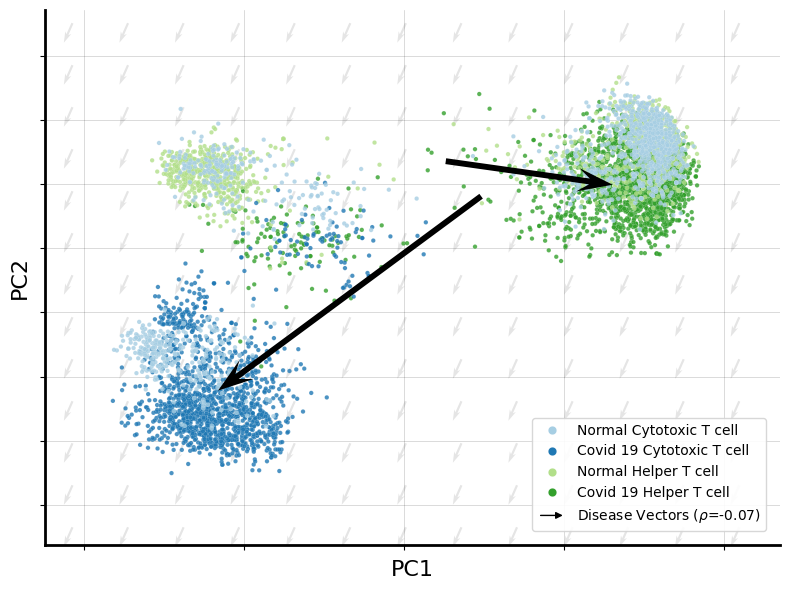

In [91]:
from sklearn.decomposition import PCA
import scanpy as sc, pandas as pd, numpy as np
import itertools
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")

DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza', 'lung adenocarcinoma'],
                'neurological': ['Alzheimer disease', 'Parkinson disease', 'glioblastoma'],
                'cardiometabolic': ['myocardial infarction', 'dilated cardiomyopathy', 'arrhythmogenic right ventricular cardiomyopathy']}
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
phenotypic_types = tok.phenotypic_types
diseases = sum(list(DISEASES_DICT.values()), [])

for disease in diseases[:1]: 
    if disease == 'normal': continue
    print(disease)
    embeddings = pd.read_pickle(EMBEDDINGS_DIR + disease + "_embeddings.pkl")
    df = pd.DataFrame({'embedding': embeddings[0].tolist(), 'y_pred': embeddings[1].tolist()}
                   | {phenotypic_types[idx]:embeddings[2][:, idx] for idx in range(len(phenotypic_types))})
    df[['disease', 'cell_type']] = df[['disease', 'cell_type']].applymap(lambda x: x[1:-1])
    #df = df[df['sex']=='[female]']
    df[['UMAP1', 'UMAP2']] = PCA(2).fit_transform(np.array(df['embedding'].tolist())).tolist()
    disease_cell_types = df['cell_type'].unique().tolist()
    disease = normalise_str(disease)[1:-1]
    for cell_type_pair in itertools.combinations(disease_cell_types, 2):
            ds = df[(df['disease'].isin([disease, 'normal'])) & (df['cell_type'].isin(cell_type_pair))]
            labels = ds.apply(lambda x: f"{x['disease']} {x['cell_type']}", axis=1)
            display(ds.value_counts(['disease', 'cell_type']).reset_index())
            palette_dict = {f"{cond} {c}": sns.color_palette('Paired', 30)[2*i + j]
                            for i, c in enumerate(cell_type_pair) for j, cond in enumerate(["normal", disease])}
            ax = plot_umap(ds, disease, labels, palette_dict, figure_size=(8, 6), reduction="pc", fontsize=14, endotype_matching=True, marker_size=10, alpha=0.8,
                       min_samples=5,eps=3)
            break

Next we quantify how similar these disease vectors are. The implications of a disease vector a single translation for disease across tissues could lead to understanding the representations of tissues in other diseases. 

We can also compute the instrinsic nature of the vector with a cosine construction We denote $A$ Alzheimer's, $P$ Parkinson's, $O$ Oligodendrocytes, $M$ Microglial Cells. Missing $AO$ disease vector, can we construct a projection based disease vector. $$AO = cos(AM, PM)PO + O$$

The exact details can be found in get_disease_vectors.py

In [92]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'
results = pd.read_pickle(EMBEDDINGS_DIR + "disease_vector_results.pkl")
similarity_matrices = pd.read_pickle( EMBEDDINGS_DIR + "disease_vector_similarity_matrices.pkl")

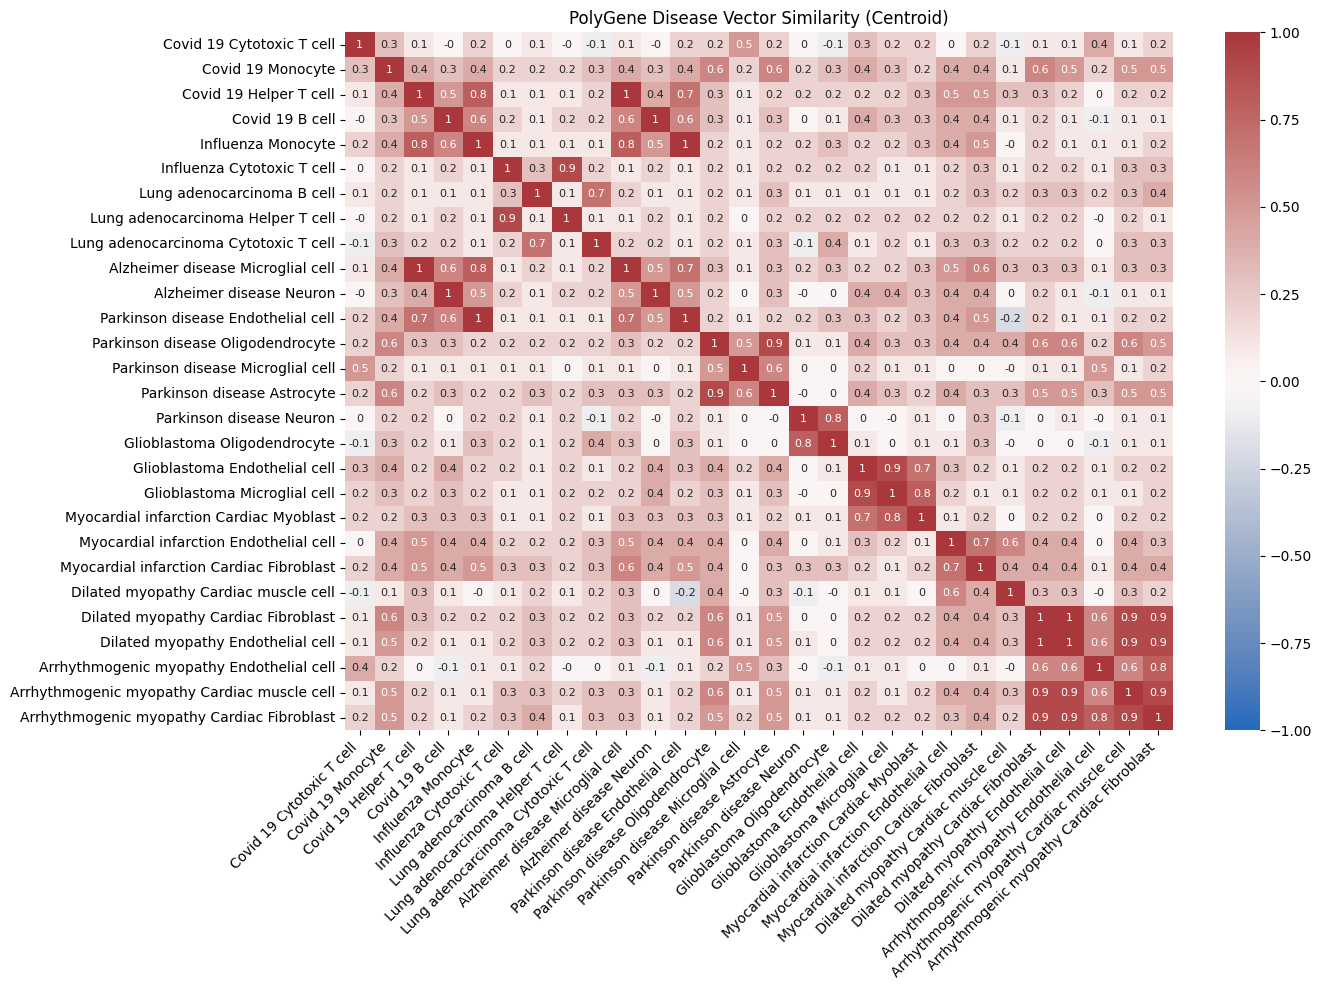

In [93]:
fontsize=10
palette = "RdYlBu_r" # "vlag"
palette = "magma"
palette = "vlag"
round_digits = 1
round_technique =  "trun" # or round
dv = pd.DataFrame(results)
for vector_type in ['centroid']:#, 'raw_centroid', 'vectors' , 'raw_vectors']:
    matrix = similarity_matrices[vector_type]
    fig, ax = plt.subplots(1,1, figsize=(14,10), dpi= 300 if SAVE else 100)

    labels = [' '.join([word.capitalize() for word in x.replace(' disease', '').split(' ')]) for x in dv.columns]
    labels = [' '.join(label.split('_'))
                      .replace('Cd4 positive alpha beta t cell', 'Helper T cell').replace('Cd8 positive alpha beta t cell', 'Cytotoxic T cell'
                    ).replace("Classical monocyte", "Monocyte").replace('Fibroblast of cardiac tissue', 'Cardiac Fibroblast'
                ).replace('Cardiac muscle myoblast', 'Cardiac Myoblast').replace('Cardiac endothelial cell', 'Endothelial cell'
                    ).replace('Arrhythmogenic right ventricular', 'Arrhythmogenic').replace('cardiomyopathy', 'myopathy') for label in labels]
    

    vmin, vmax, center = (-1, 1, 0) if "centroid" in vector_type else (-0.5, 0.5, 0)
    if round_technique == "trunc": matrix = matrix.applymap(lambda x: int(x * 10**round_digits) / (10**round_digits))
    sns.heatmap(matrix.round(round_digits), annot=True, cmap=palette, center=center, vmin=vmin, vmax=vmax,
                 xticklabels=labels, yticklabels=labels, annot_kws={"size": fontsize-2},ax=ax)

    title = "PolyGene Disease Vector Similarity" if not "raw" in vector_type else "scRNA Disease Vector Similarity"
    title += " (Centroid)" if "centroid" in vector_type else " (Population)"
    plt.title(title, fontsize=fontsize+2)
    plt.xticks(rotation=45, ha="right", fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)
    if SAVE: plt.savefig(f'../figures/figure4/{vector_type}_heatmap.svg', dpi=300, transparent=True)
    plt.tight_layout()
    plt.show()

Next we explore the euclidean geometrical properties of this latent space

LEFT TO DO Attribution Analysis. show open targets benchmark in faithfulness plots. disease vector IG. do pruning but for each input

In [94]:
from sklearn.decomposition import PCA
import scanpy as sc, pandas as pd, numpy as np
import itertools
import sys
from tqdm import tqdm
sys.path.append('../../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str
m, tok = load_trained_model("../../../runs/gesam_polygene_run_4/")
phenotypic_types = tok.phenotypic_types

DISEASES_DICT = {'respiratory': ['COVID-19','influenza','lung adenocarcinoma'],
                 'neurological': ['Alzheimer disease','Parkinson disease','glioblastoma'],
                 'cardiometabolic': ['myocardial infarction','dilated cardiomyopathy','arrhythmogenic right ventricular cardiomyopathy']}
EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/vector_data/'

from scipy.spatial.distance import cosine

def parallelogram_score(A,B,C,D):
    u,u_p=B-A,D-C
    v,v_p=D-A,B-C
    s1,s2=cosine(u,u_p),cosine(v,v_p)
    return np.sqrt(np.clip((1 - s1) * (1 - s2), 0, 1))

def planarity_score(p1,p2,p3,q,eps=1e-12):
    u,v,w=p2-p1,p3-p1,q-p1
    U=np.stack([u,v],axis=1)
    coef,*_=np.linalg.lstsq(U,w,rcond=None)
    r=w-U@coef
    d=np.linalg.norm(r)
    s=max(np.linalg.norm(u),np.linalg.norm(v),eps)
    return 1/(1+d/s)

diseases=sum(list(DISEASES_DICT.values()), [])

cell_count=1000
cell_count_vectors=100
iterations=100

results_tmp={}
for disease in tqdm(diseases, desc="Disease Vectors"):
    if disease=='normal': continue
    embeddings=pd.read_pickle(EMBEDDINGS_DIR+disease+"_embeddings.pkl")
    df=pd.DataFrame(
        {'embedding':embeddings[0].tolist()}
        |{phenotypic_types[idx]:embeddings[2][:,idx] for idx in range(len(phenotypic_types))}
    )
    df[['disease','cell_type']]=df[['disease','cell_type']].applymap(lambda x: x[1:-1])
    disease_norm=normalise_str(disease)[1:-1]
    for _ in tqdm(range(iterations), desc="Bootstrap", leave=False):
        df_s=df.sample(cell_count, replace=True)
        disease_vectors={}
        for cell_type in df_s['cell_type'].unique():
            cell_group=df_s[df_s['cell_type']==cell_type]
            if "normal" not in cell_group['disease'].values or disease_norm not in cell_group['disease'].values: continue
            normal_embeddings=np.array(cell_group[cell_group['disease']=='normal']['embedding'].tolist())
            disease_embeddings=np.array(cell_group[cell_group['disease']==disease_norm]['embedding'].tolist())
            if len(normal_embeddings)==0 or len(disease_embeddings)==0: continue
            disease_vectors[f"{disease_norm} {cell_type}"]=disease_embeddings[:cell_count_vectors].mean(0)
            disease_vectors[f"normal {cell_type}"]=normal_embeddings[:cell_count_vectors].mean(0)
        valid_cell_types=sorted({k.split(' ',1)[1] for k in disease_vectors.keys() if k.startswith('normal ') and f"{disease_norm} {k.split(' ',1)[1]}" in disease_vectors})
        for cell1,cell2 in itertools.combinations(valid_cell_types, r=2):
            A=disease_vectors[f"{disease_norm} {cell1}"]
            B=disease_vectors[f"normal {cell1}"]
            C=disease_vectors[f"{disease_norm} {cell2}"]
            D=disease_vectors[f"normal {cell2}"]
            p=parallelogram_score(A,B,C,D)
            q=planarity_score(A,B,C,D)
            key=(disease_norm,cell1,cell2)
            if key not in results_tmp: results_tmp[key]={'parallelogram':[],'planarity':[]}
            results_tmp[key]['parallelogram'].append(p)
            results_tmp[key]['planarity'].append(q)

results={}
for key,vals in results_tmp.items():
    p=np.array(vals['parallelogram']); q=np.array(vals['planarity'])
    p_ci=np.percentile(p,[2.5,97.5]); q_ci=np.percentile(q,[2.5,97.5])
    results[key]={
        'parallelogram':{'mean':float(p.mean()),'ci_low':float(p_ci[0]),'ci_high':float(p_ci[1])},
        'planarity':{'mean':float(q.mean()),'ci_low':float(q_ci[0]),'ci_high':float(q_ci[1])}
    }
# 15s to run

Disease Vectors:   0%|          | 0/9 [00:00<?, ?it/s]

Disease Vectors: 100%|██████████| 9/9 [00:10<00:00,  1.18s/it]


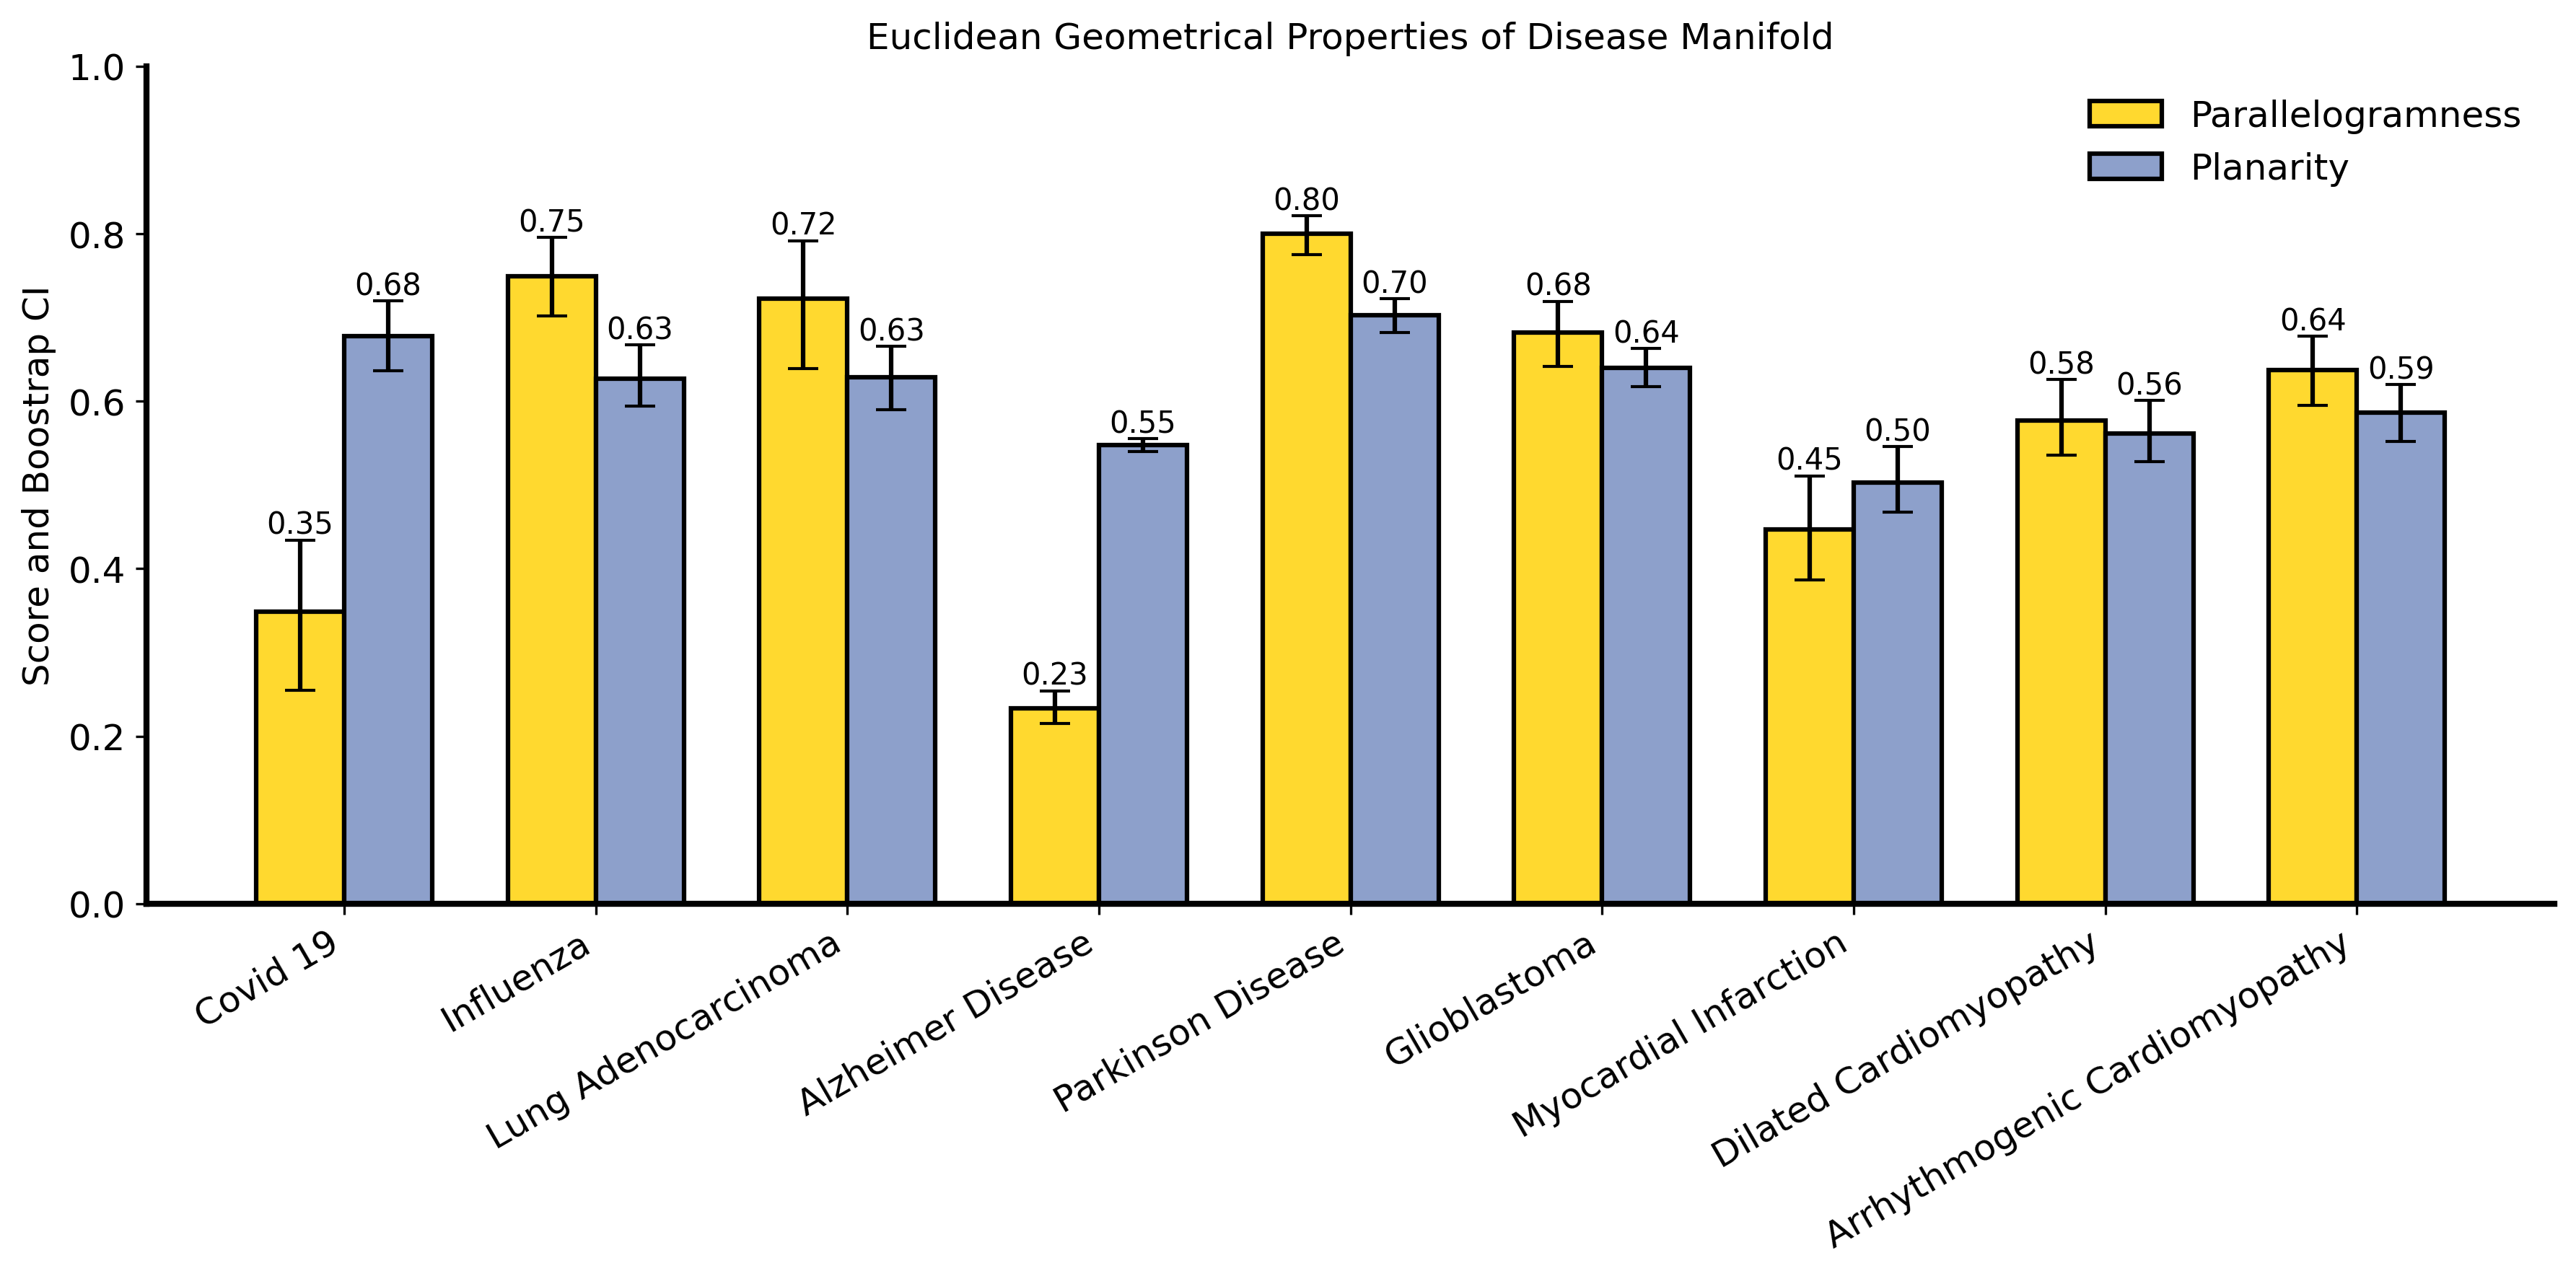

In [95]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
fontsize = 12
def plot_scores(results_df, average_per_disease=False):
    metric_labels = {
    "parallelogram": r"Parallelogramness",# = $\sqrt{(s_1)(s_2)}$",
    "planarity": r"Planarity",# = $\frac{1}{1+d/s}$",
    }
    long_df=results_df.stack(list(range(results_df.columns.nlevels))).reset_index(name='stats')
    long_df=pd.concat([long_df.drop(columns='stats'),pd.json_normalize(long_df['stats'])],axis=1).rename(columns={'level_0':'metric','level_1':'disease','level_2':'cell_a','level_3':'cell_b'})
    if average_per_disease:
        plot_df=long_df.groupby(['metric','disease'],as_index=False).agg(mean=('mean','mean'),ci_low=('ci_low','mean'),ci_high=('ci_high','mean'))
        plot_df['label']=plot_df['disease']
        desired_order = ["covid_19", "influenza", "lung_adenocarcinoma", "alzheimer_disease", "parkinson_disease", "glioblastoma", "myocardial_infarction", "dilated_cardiomyopathy", "arrhythmogenic_right_ventricular_cardiomyopathy"]
        plot_df['disease_order'] = pd.Categorical(plot_df['disease'], categories=desired_order, ordered=True).codes
        plot_df = plot_df.sort_values('disease_order')
    else:
        long_df['label']=long_df['disease']+'_'+long_df['cell_a']+'_'+long_df['cell_b']
        plot_df=long_df[['metric','label','mean','ci_low','ci_high']]
    plt.figure(figsize=(12,6),dpi=300 if SAVE else 300)
    ax=plt.gca();width=0.35;x=np.arange(plot_df['label'].nunique());palette=sns.color_palette('Set2_r',2)
    for i,m in enumerate(plot_df['metric'].unique()):
        subset=plot_df[plot_df['metric']==m]
        yerr=np.vstack([subset['mean']-subset['ci_low'],subset['ci_high']-subset['mean']])
        bars=ax.bar(x+i*width,subset['mean'],width=width,yerr=yerr,capsize=5,label=metric_labels[m],color=palette[i],edgecolor='k',lw=1.5)
        for idx, (bar,val) in enumerate(zip(bars,subset['mean']), start=0):
            ax.text(bar.get_x()+bar.get_width()/2,val + yerr[1, idx] ,
                    f"{val:.2f}",ha='center',va='bottom',fontsize=fontsize-2) 
    ax.set_ylim(0,1)
    ax.set_xticks(x+width/2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(2)
    
    labels = [label.replace('Arrhythmogenic Right Ventricular', 'Arrhythmogenic') for label in plot_df['label'].drop_duplicates().str.replace('_',' ').str.title()]
    #print(plot_df)
    ax.set_xticklabels(labels,rotation=30,ha='right', fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    ax.legend(edgecolor='k', loc="upper right", fontsize=fontsize, frameon=False)
    ax.set_title("Euclidean Geometrical Properties of Disease Manifold")
    ax.set_ylabel('Score and Boostrap CI', fontsize=fontsize)
    plt.tight_layout()
    if SAVE: plt.savefig('../figures/figure4/euclidean_properties.svg', dpi=300, transparent=True)
    plt.show()

plot_scores(pd.DataFrame(results), average_per_disease=True)

#### This is a strong motivation that shows the power of tangent map analogy and analogical reasoning but also shows it is not the full picture and this manifold is a curved manifold with complex topology.